# 01 Exploratory Data Analysis

This notebook is executed and includes outputs plus interpretation notes.

## Goal
Summarize the national incident dataset and inspect patterns by year, province, sector, severity, incident type, and OSB exposure.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
from IPython.display import Image, display
clean = pd.read_excel('../data/processed/kmo_incidents_clean.xlsx')
panel = pd.read_excel('../data/processed/city_year_osb_panel.xlsx')
print(clean.shape)
clean.groupby('year').size().rename('incident_count').reset_index()

(3852, 42)


,year,incident_count
0,2017,153
1,2018,436
2,2019,541
3,2020,493
4,2021,394
5,2022,587
6,2023,528
7,2024,720


In [2]:
annual_type = clean.groupby(['year', 'olay_turu']).size().unstack(fill_value=0)
annual_type['total'] = annual_type.sum(axis=1)
annual_type

olay_turu,explosion,fire,unknown,total
year,,,,
2017,11,62,80,153
2018,52,384,0,436
2019,39,502,0,541
2020,52,441,0,493
2021,36,358,0,394
2022,36,551,0,587
2023,33,495,0,528
2024,26,694,0,720


### Interpretation
The 2024 manual table adds a large increase in observed events: 720 records, mostly fires. Because this is a reporting dataset rather than a complete official registry, annual changes should be interpreted as reported/compiled incidents, not necessarily true national incidence.

In [3]:
top_provinces = clean['il'].value_counts().head(15).rename_axis('province').reset_index(name='incidents')
top_provinces

,province,incidents
0,İstanbul,993
1,İzmir,399
2,Bursa,254
3,Kocaeli,223
4,Tekirdağ,187
5,Ankara,114
6,Sakarya,87
7,Denizli,74
8,Adana,72
9,Gaziantep,56


In [4]:
sector_summary = clean['sektor_std'].value_counts().rename_axis('sector').reset_index(name='incidents')
sector_summary.head(12)

,sector,incidents
0,"Ağaç,Kağıt,Mobilya",818
1,Bilinmeyen,691
2,Tekstil,625
3,Metal,600
4,"Kauçuk,Plastik",382
5,Gıda,341
6,"Petrokimya,Yağ",135
7,"Çimento,Cam,Seramik",98
8,Enerji,65
9,Boya,50


In [5]:
severity_by_sector = pd.crosstab(clean['sektor_std'], clean['severity'], normalize='index').round(3)
severity_by_sector.loc[sector_summary.head(8)['sector']]

severity,high,low,medium
sektor_std,,,
"Ağaç,Kağıt,Mobilya",0.026,0.919,0.055
Bilinmeyen,0.013,0.958,0.029
Tekstil,0.029,0.909,0.062
Metal,0.068,0.842,0.090
"Kauçuk,Plastik",0.018,0.940,0.042
Gıda,0.041,0.906,0.053
"Petrokimya,Yağ",0.081,0.822,0.096
"Çimento,Cam,Seramik",0.031,0.908,0.061


### Interpretation
Raw incident counts are concentrated in industrial provinces and common manufacturing sectors. The normalized severity table is more informative than raw sector counts because it asks whether the mix of low/medium/high severity differs across sectors.

In [6]:
province_exposure = clean.groupby('il').agg(
    incidents=('Tarih','count'),
    osb_parcels=('osb_parcels','first'),
    osb_area_hectare=('osb_area_hectare','first')
).query('osb_parcels > 0').copy()
province_exposure['incidents_per_1000_parcels'] = province_exposure['incidents'] / province_exposure['osb_parcels'] * 1000
province_exposure.sort_values('incidents_per_1000_parcels', ascending=False).head(15)

,incidents,osb_parcels,osb_area_hectare,incidents_per_1000_parcels
il,,,,
İstanbul,993,1863,2417.60,533.011272
Muğla,21,104,234.16,201.923077
Bartın,8,47,187.50,170.212766
Denizli,74,510,1347.95,145.098039
İzmir,399,3487,5070.78,114.425007
Kocaeli,223,2129,4032.00,104.744011
Düzce,36,344,1044.60,104.651163
Bursa,254,2688,5723.07,94.494048
Aydın,48,512,1838.00,93.750000


### Interpretation
OSB exposure changes the story: high raw incident provinces are not automatically the highest-risk provinces. The exposure-adjusted metric, incidents per 1,000 OSB parcels, is a simple way to separate industrial capacity from incident intensity.

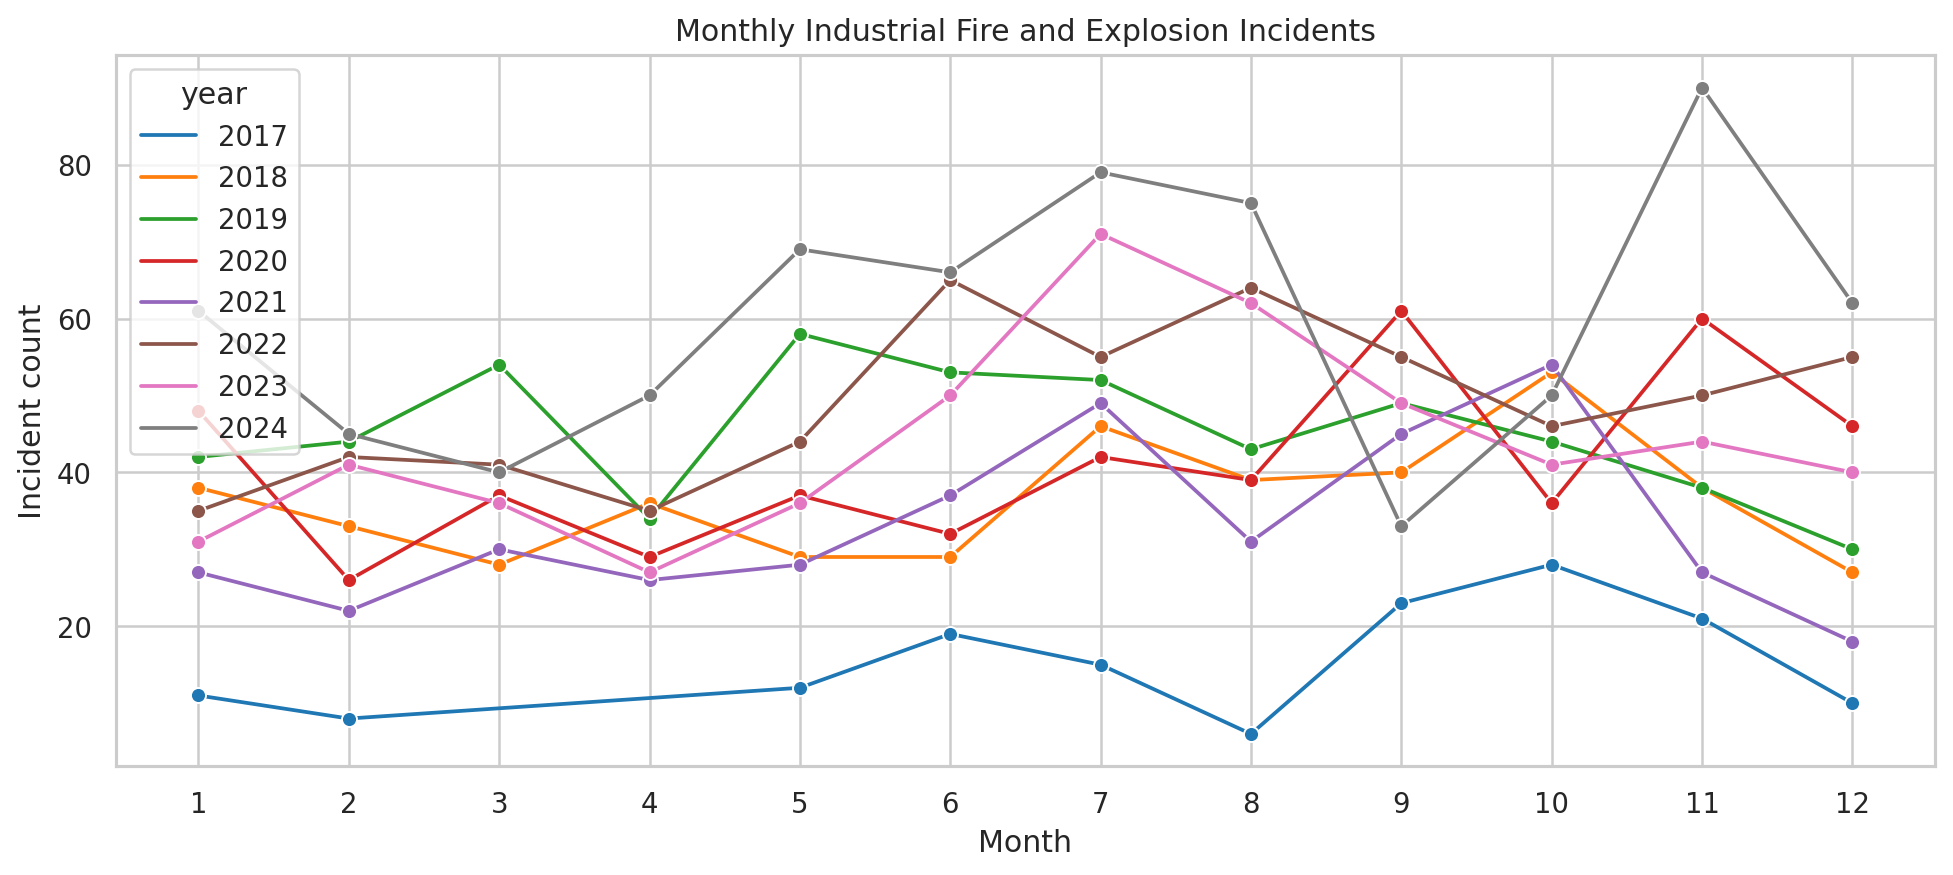

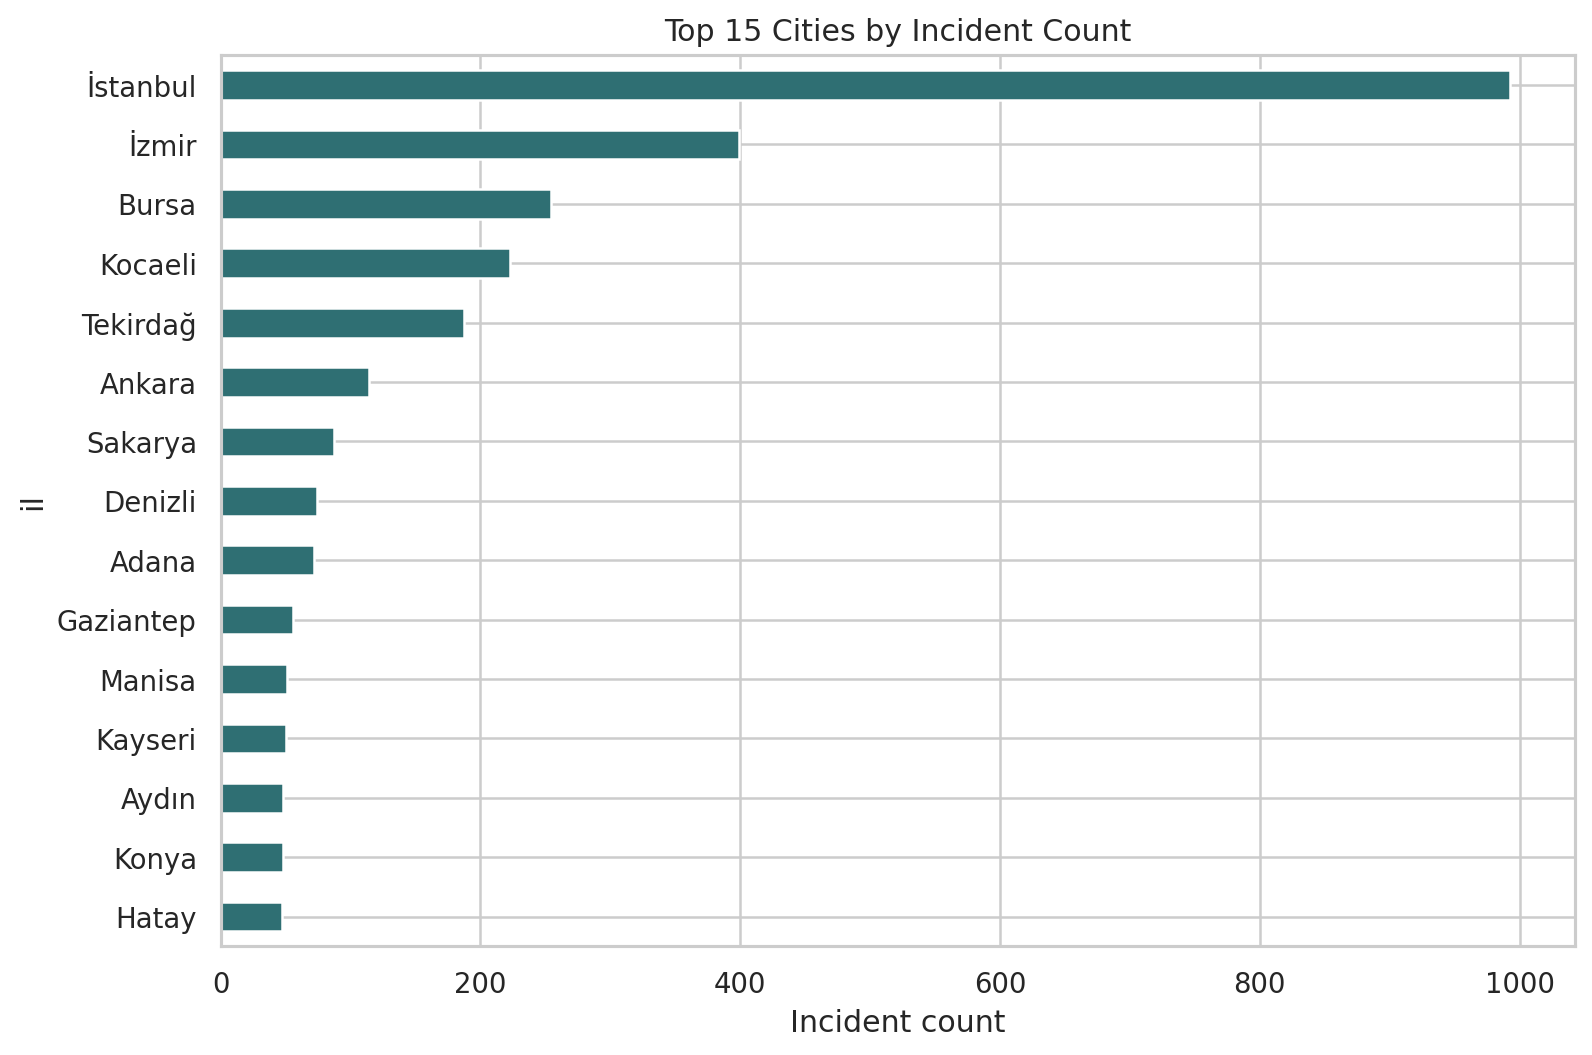

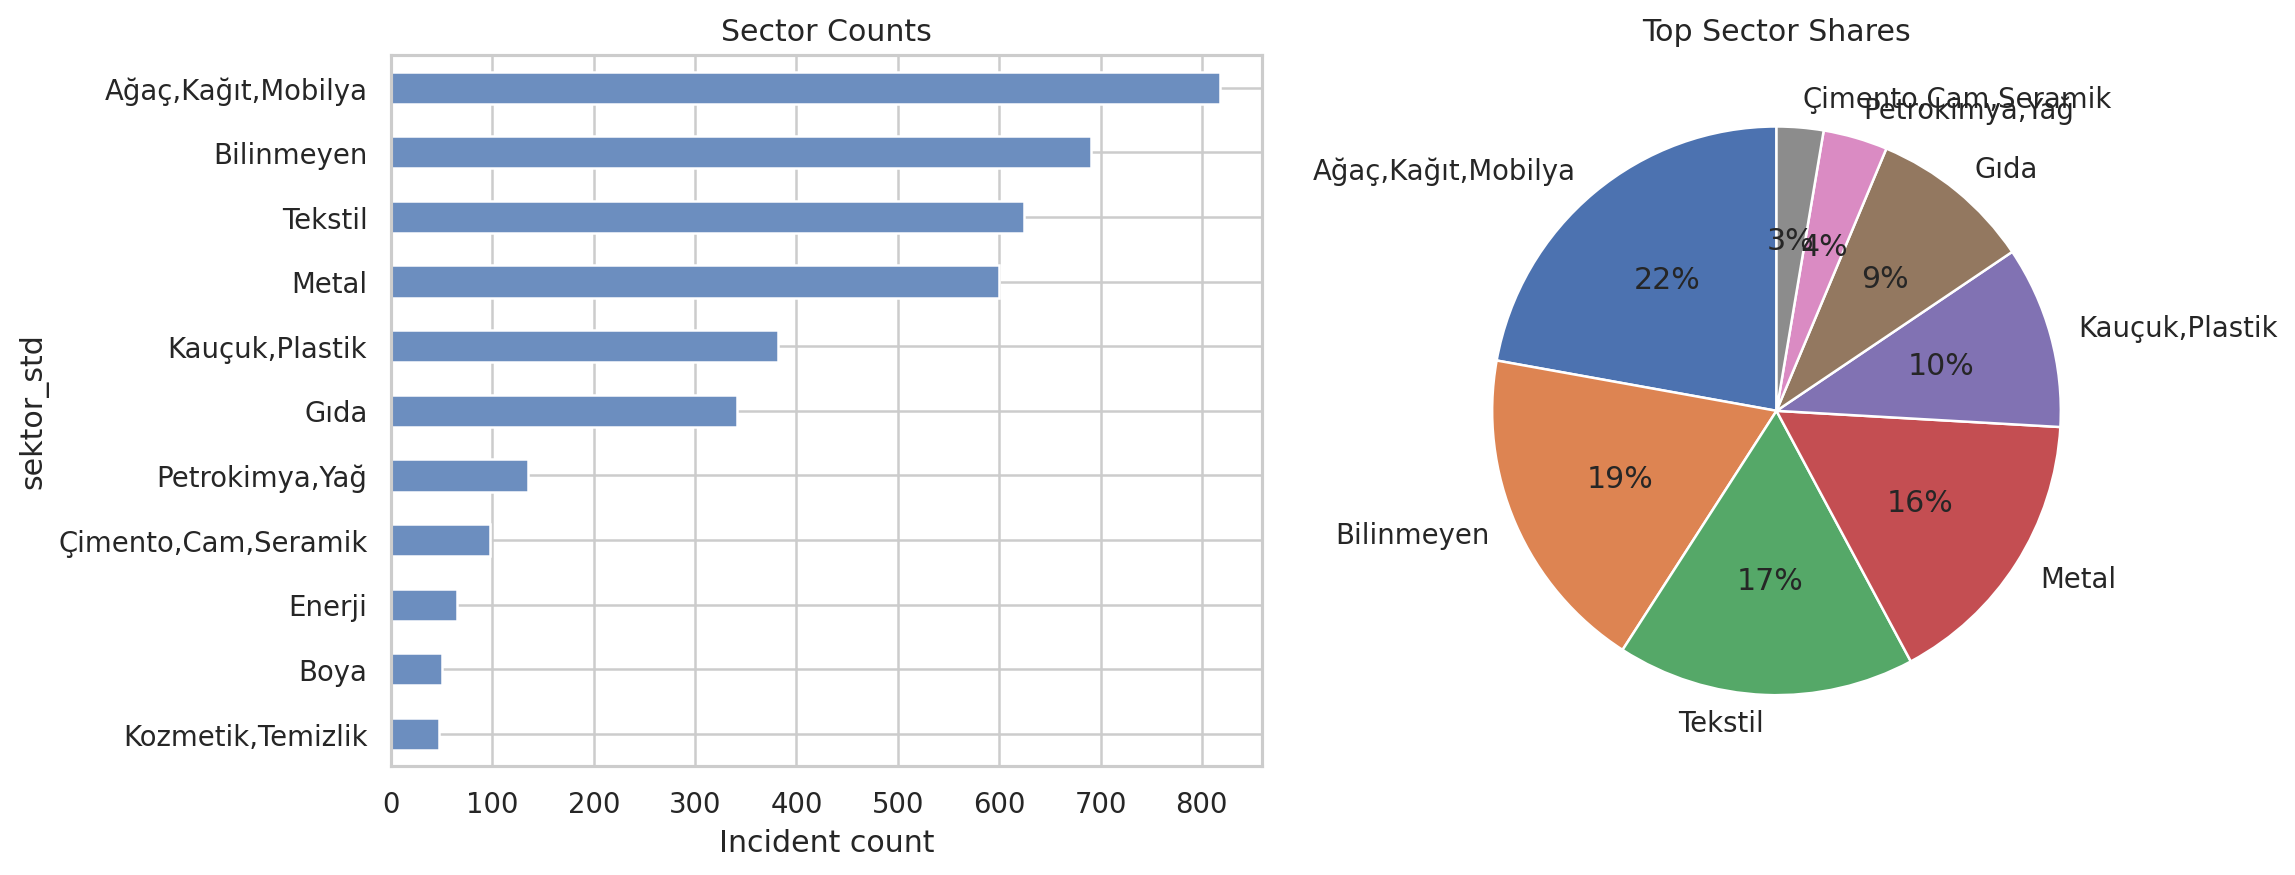

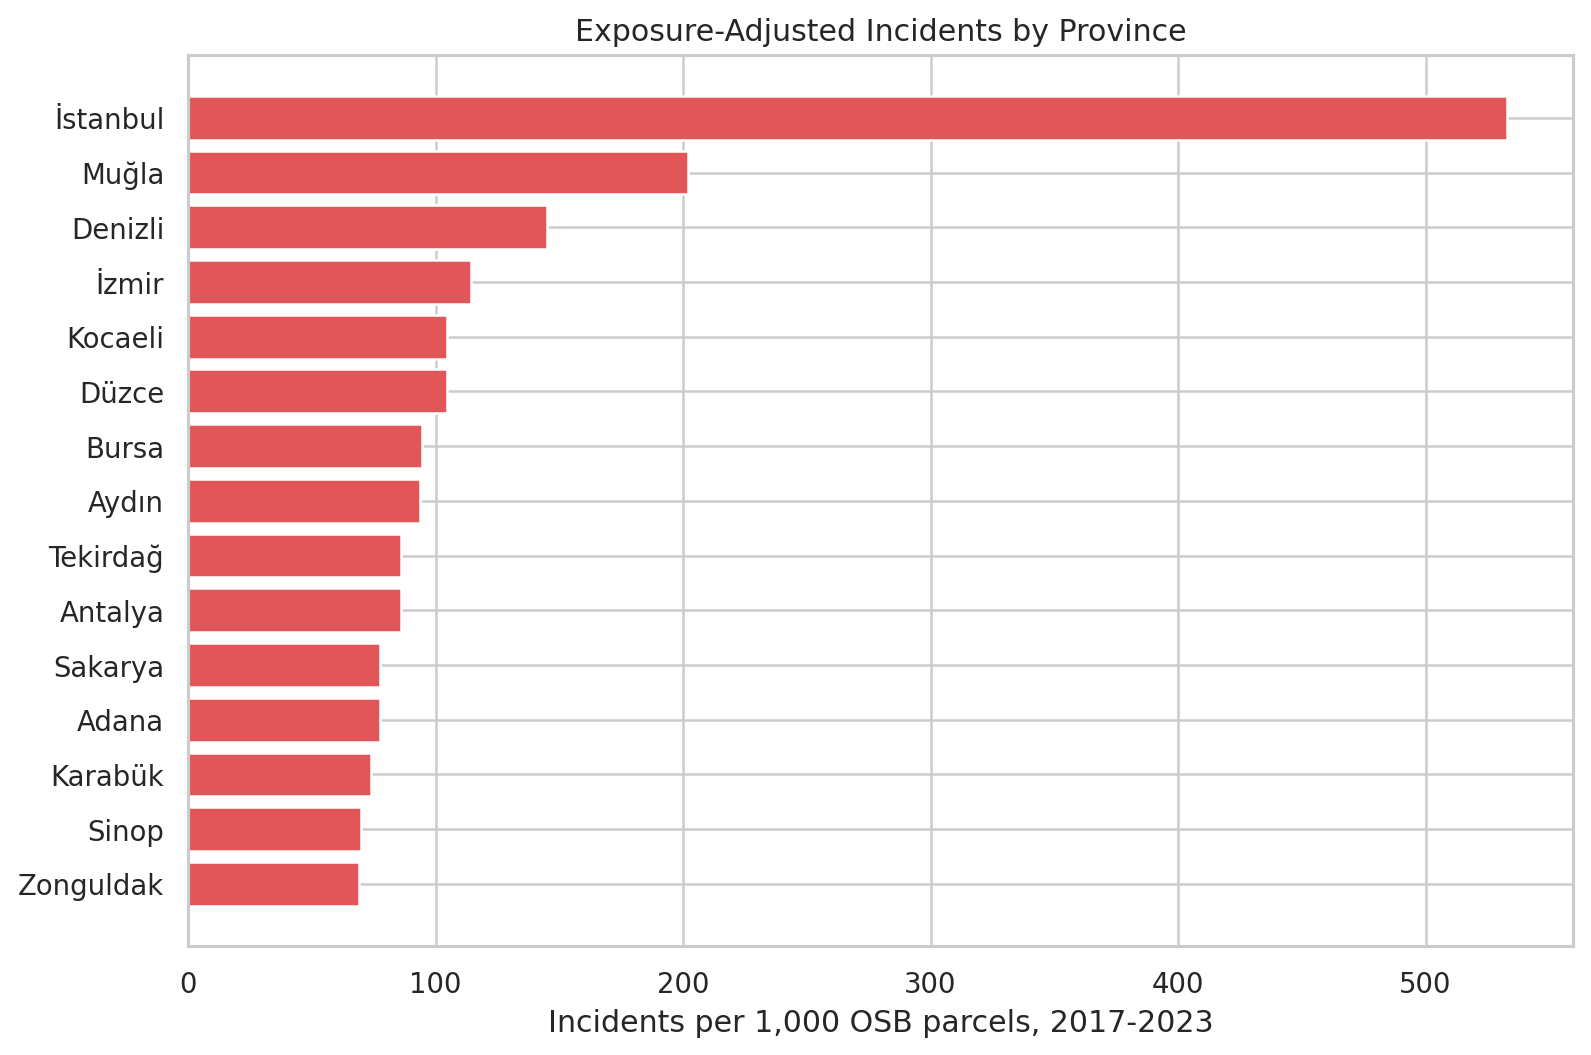

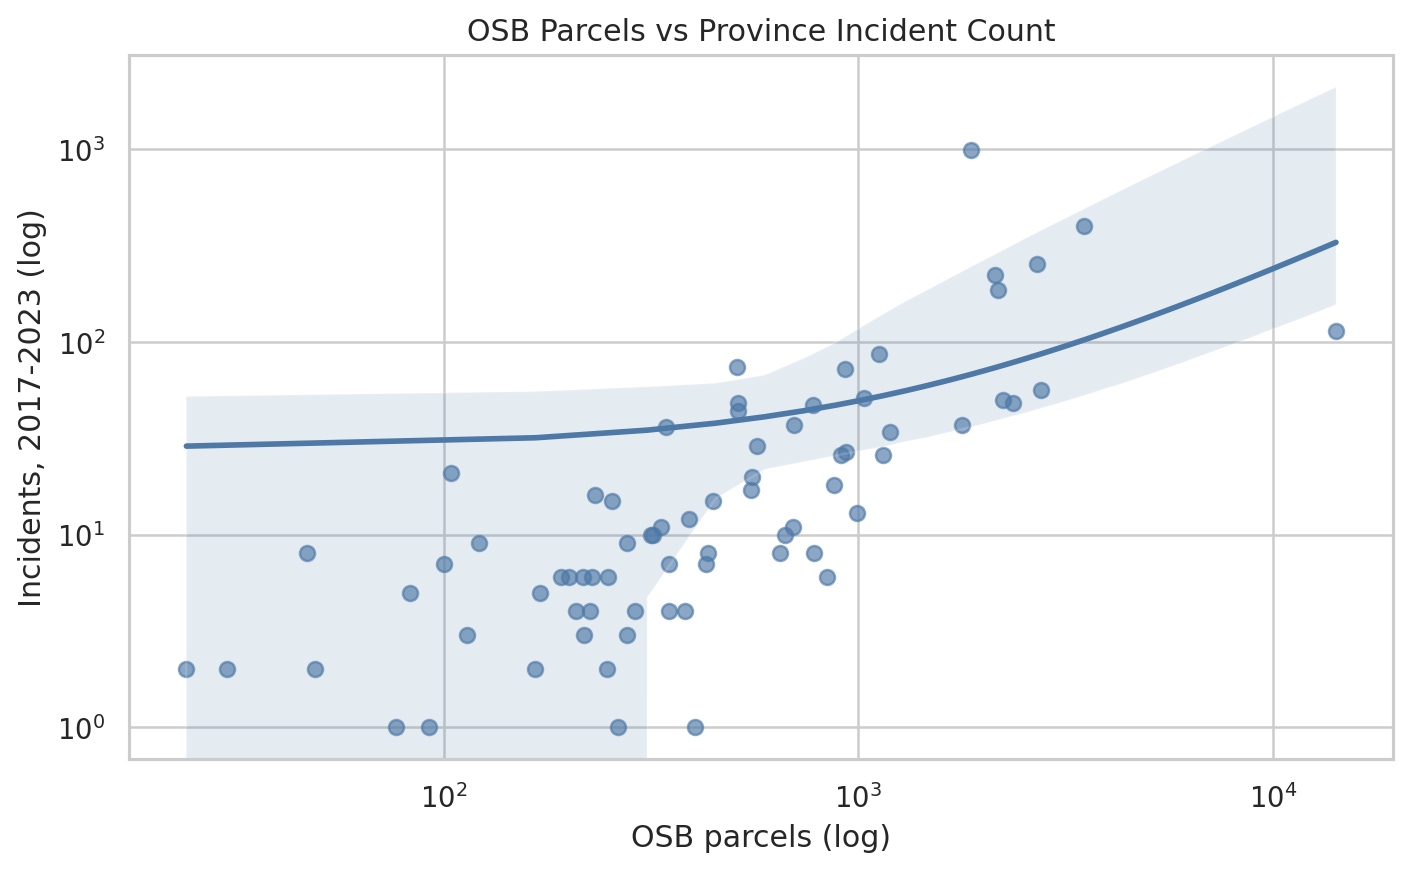

In [7]:
for fig in [
    '../figures/01_monthly_fire_counts.png',
    '../figures/02_top_cities.png',
    '../figures/03_sector_distribution.png',
    '../figures/07_istanbul_districts.png',
    '../figures/09_temp_vs_fire_count.png',
]:
    display(Image(filename=fig))

### Figure Interpretation
The figures show that the strongest descriptive patterns are spatial and sectoral rather than purely temporal. The OSB parcel/area plots support the revised research direction: incident counts should be read relative to industrial exposure.